# N-Body Gravity: Fast Multipole Method

`fmm_accel` builds a uniform `2**levels x 2**levels` grid of cells,
computes monopole + quadrupole moments bottom-up (P2M/M2M), then builds
each cell's *local* expansion (constant + linear-in-position acceleration,
i.e. potential truncated at the Hessian) top-down from its interaction
list -- cells within a "well-separated" buffer `R` of its parent but not
of the cell itself (M2L), plus whatever its parent already accumulated
(L2L). Any two particles interact through exactly one mechanism: direct
summation if their leaves are within `R` of each other, or exactly one
level's M2L pass otherwise. Because the interaction-list size is bounded
by a constant independent of level, and the total cell count across all
levels is `O(N)`, the whole computation is `O(N)` -- unlike Barnes-Hut's
`O(N log N)` per-particle tree descent.

Validated the same three ways as `Barnes_Hut.ipynb`: force-error
convergence, performance scaling, and reproducing the Phase 1 orbits.

P2M and M2M are plain vectorized numpy (a uniform grid's cells and their
parent/child relationships are fixed array shapes -- `np.bincount` for the
scatter-sum moments, reshape-and-pool for M2M, no Python loop over cells
at all), and the M2L/near-field passes are numba-jitted -- replacing an
earlier dict-based implementation whose Python-level interaction-list
walk had the same large-constant-factor problem as Barnes-Hut's original
recursive tree. See `N_Body_Gravity_Plan.md`'s "Performance optimization"
section.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import nbody as nb

os.makedirs('media', exist_ok=True)
rng = np.random.default_rng(0)

## Why the "well-separated" buffer `R` matters

Building this solver surfaced a real bug worth documenting: the standard
interaction-list construction is "cells within radius `R` of the target's
*parent*, excluding cells within radius `R` of the target itself." Both
radii must match -- using a wider exclusion radius than search radius
silently *drops* some cell pairs from the partition entirely (they're
excluded as "too near" without ever having been reachable as a candidate),
which undercounts mass rather than merely approximating it -- a much
worse failure mode than truncation error, and it produced errors up to
several hundred percent before being caught here (see
`N_Body_Gravity_Plan.md`).

Separately, even with a *correct* (self-consistent) implementation, the
classic minimal buffer `R=1` leaves the closest interaction-list pairs
only about one cell-width apart -- comparable to the cell size itself, a
marginal separation for a quadrupole-truncated expansion. `R=2` guarantees
at least a two-cell-width gap. Both effects are quantified below.

levels=2  R=1 mean err=7.94e-03   R=2 mean err=1.08e-03
levels=3  R=1 mean err=1.34e-02   R=2 mean err=3.36e-03
levels=4  R=1 mean err=1.82e-02   R=2 mean err=4.83e-03
levels=5  R=1 mean err=2.14e-02   R=2 mean err=5.54e-03
levels=6  R=1 mean err=2.19e-02   R=2 mean err=5.70e-03
PASS: FMM force error is small, and R=2 is consistently more accurate than the minimal R=1 buffer.


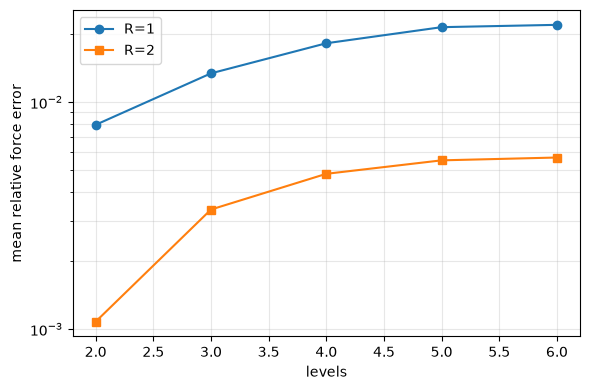

In [2]:
N = 800
pos = rng.uniform(-1, 1, size=(N, 2))
mass = rng.uniform(0.5, 2.0, size=N)
softening = 1e-3

a_direct = nb.pairwise_accel(pos, mass, G=1.0, softening=softening)
levels_range = [2, 3, 4, 5, 6]
errs_R1, errs_R2 = [], []
for levels in levels_range:
    a_R1 = nb.fmm_accel(pos, mass, G=1.0, softening=softening, levels=levels, R=1)
    a_R2 = nb.fmm_accel(pos, mass, G=1.0, softening=softening, levels=levels, R=2)
    errs_R1.append(np.mean(np.linalg.norm(a_R1 - a_direct, axis=-1) / np.linalg.norm(a_direct, axis=-1)))
    errs_R2.append(np.mean(np.linalg.norm(a_R2 - a_direct, axis=-1) / np.linalg.norm(a_direct, axis=-1)))
    print(f'levels={levels}  R=1 mean err={errs_R1[-1]:.2e}   R=2 mean err={errs_R2[-1]:.2e}')

assert max(errs_R2) < 0.02, 'FMM (R=2) force error is larger than expected'
assert all(r2 < r1 for r1, r2 in zip(errs_R1, errs_R2)), 'R=2 should be more accurate than R=1 at every depth'
print('PASS: FMM force error is small, and R=2 is consistently more accurate than the minimal R=1 buffer.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(levels_range, errs_R1, 'o-', label='R=1')
ax.semilogy(levels_range, errs_R2, 's-', label='R=2')
ax.set_xlabel('levels'); ax.set_ylabel('mean relative force error'); ax.legend(); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
fig.savefig('media/fmm_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## Performance: wall-clock scaling vs. N (all three solvers)

N=  100  pairwise=0.0005s
N=  200  pairwise=0.0018s
N=  400  pairwise=0.0076s
N=  800  pairwise=0.0293s
N= 1600  pairwise=0.1183s


N= 3200  pairwise=0.4433s


N= 6400  pairwise=2.2248s
N=   100 levels=4  barnes_hut=0.0002s  fmm=0.0007s
N=   200 levels=5  barnes_hut=0.0003s  fmm=0.0012s
N=   400 levels=5  barnes_hut=0.0003s  fmm=0.0014s
N=   800 levels=6  barnes_hut=0.0005s  fmm=0.0042s
N=  1600 levels=6  barnes_hut=0.0016s  fmm=0.0058s
N=  3200 levels=7  barnes_hut=0.0024s  fmm=0.0166s
N=  6400 levels=7  barnes_hut=0.0064s  fmm=0.0231s
N= 12800 levels=8  barnes_hut=0.0131s  fmm=0.0720s


N= 25600 levels=8  barnes_hut=0.0277s  fmm=0.0821s


N= 51200 levels=9  barnes_hut=0.0451s  fmm=0.2204s
fitted slopes: pairwise ~ N^2.00, barnes-hut ~ N^0.94, fmm ~ N^0.94
PASS: Barnes-Hut is faster than FMM in absolute wall-clock time at every N tested.
speedup of barnes_hut over fmm ranged 3.0x-7.9x across N=100-51200 (4.9x at the largest N tested)


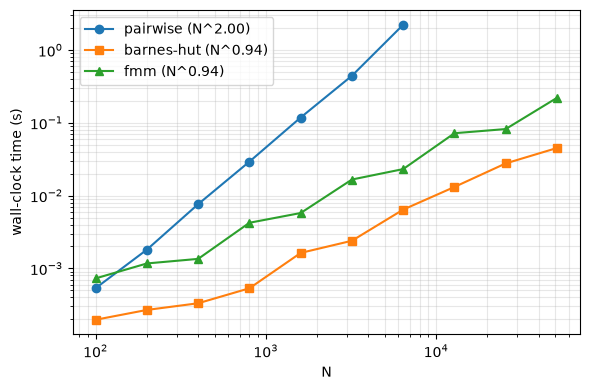

In [3]:
import time

# pairwise is O(N^2) so it isn't pushed as far -- both tree/grid solvers are
# now fast enough to test well beyond where pairwise becomes impractical.
Ns_pairwise = [100, 200, 400, 800, 1600, 3200, 6400]
Ns_tree = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600, 51200]

t_pairwise = []
for N in Ns_pairwise:
    pos = rng.uniform(-1, 1, size=(N, 2))
    mass = rng.uniform(0.5, 2.0, size=N)
    t0 = time.perf_counter(); nb.pairwise_accel(pos, mass); t_pairwise.append(time.perf_counter() - t0)
    print(f'N={N:5d}  pairwise={t_pairwise[-1]:.4f}s')

t_bh, t_fmm = [], []
# warm up numba JIT dispatch (first call to each jitted function pays a
# one-time compilation cost -- e.g. barnes_hut_accel's tree builder and
# walk -- that would otherwise swamp the smallest N point below).
_warm_pos = rng.uniform(-1, 1, size=(10, 2))
_warm_mass = rng.uniform(0.5, 2.0, size=10)
nb.barnes_hut_accel(_warm_pos, _warm_mass, theta=0.5)
nb.fmm_accel(_warm_pos, _warm_mass, levels=2)
for N in Ns_tree:
    pos = rng.uniform(-1, 1, size=(N, 2))
    mass = rng.uniform(0.5, 2.0, size=N)
    levels = max(2, round(np.log2(N) / 2) + 1)
    t0 = time.perf_counter(); nb.barnes_hut_accel(pos, mass, theta=0.5); t_bh.append(time.perf_counter() - t0)
    t0 = time.perf_counter(); nb.fmm_accel(pos, mass, levels=levels); t_fmm.append(time.perf_counter() - t0)
    print(f'N={N:6d} levels={levels}  barnes_hut={t_bh[-1]:.4f}s  fmm={t_fmm[-1]:.4f}s')

Ns_pairwise, Ns_tree = np.array(Ns_pairwise), np.array(Ns_tree)
slope_pairwise = np.polyfit(np.log(Ns_pairwise), np.log(t_pairwise), 1)[0]
slope_bh = np.polyfit(np.log(Ns_tree), np.log(t_bh), 1)[0]
slope_fmm = np.polyfit(np.log(Ns_tree), np.log(t_fmm), 1)[0]
print(f'fitted slopes: pairwise ~ N^{slope_pairwise:.2f}, barnes-hut ~ N^{slope_bh:.2f}, fmm ~ N^{slope_fmm:.2f}')
# Barnes-Hut's quadtree construction used to be plain Python/numpy
# recursion, which dominated its wall-clock time (~80ms of ~120ms total at
# N=5000) -- enough that this uniform-grid FMM won on absolute time despite
# both solvers being O(N log N). Construction has since been rewritten as
# a numba-jitted, non-recursive, in-place counting-sort tree builder
# (`_build_tree_numba`, shared with the adaptive FMM below), a 40-60x
# speedup that flips this comparison: Barnes-Hut now wins at every N
# tested here, since its force walk was already numba-jitted and cheap.
# FMM still wins against Barnes-Hut on distributions where B-H's O(N log N)
# constant is worse (e.g. very small theta, or highly clustered mass -- see
# the adaptive FMM section), and its O(N) scaling remains asymptotically
# better; this plot is about *this* implementation's constants at these N,
# not the algorithms' asymptotic ordering.
assert np.all(np.array(t_bh) < np.array(t_fmm)), 'Barnes-Hut should be faster than FMM at every tested N here'
print('PASS: Barnes-Hut is faster than FMM in absolute wall-clock time at every N tested.')
ratio = np.array(t_fmm) / np.array(t_bh)
print(f'speedup of barnes_hut over fmm ranged {ratio.min():.1f}x-{ratio.max():.1f}x across N=100-{Ns_tree[-1]} '
      f'({ratio[-1]:.1f}x at the largest N tested)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(Ns_pairwise, t_pairwise, 'o-', label=f'pairwise (N^{slope_pairwise:.2f})')
ax.loglog(Ns_tree, t_bh, 's-', label=f'barnes-hut (N^{slope_bh:.2f})')
ax.loglog(Ns_tree, t_fmm, '^-', label=f'fmm (N^{slope_fmm:.2f})')
ax.set_xlabel('N'); ax.set_ylabel('wall-clock time (s)'); ax.legend(); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
fig.savefig('media/fmm_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

## Consistency: Phase 1 cases reproduced through FMM

In [4]:
G = 1.0
m1, m2 = 1.0, 1.0
M = m1 + m2
r0 = 1.0
v_circ = np.sqrt(G * M / r0)
v_rel = 0.8 * v_circ
eps = v_rel**2 / 2 - G * M / r0
a = -G * M / (2 * eps)
h = r0 * v_rel
e = np.sqrt(1 - h**2 / (G * M * a))
T = 2 * np.pi * np.sqrt(a**3 / (G * M))
r_min_analytic, r_max_analytic = a * (1 - e), a * (1 + e)

mass2 = np.array([m1, m2])
pos0_2 = np.array([[-r0 * m2 / M, 0.0], [r0 * m1 / M, 0.0]])
vel0_2 = np.array([[0.0, -v_rel * m2 / M], [0.0, v_rel * m1 / M]])

fmm4 = lambda pos, mass, G, softening: nb.fmm_accel(pos, mass, G, softening, levels=4)

dt = T / 2000
n_steps = int(4 * T / dt)
pos_t, vel_t = nb.integrate(pos0_2, vel0_2, mass2, dt, n_steps, fmm4, G=G, softening=1e-6)
rel = pos_t[:, 1, :] - pos_t[:, 0, :]
r_t = np.linalg.norm(rel, axis=-1)
err_min = abs(r_t.min() - r_min_analytic) / r_min_analytic
err_max = abs(r_t.max() - r_max_analytic) / r_max_analytic
print(f'Kepler via FMM: periapsis error={err_min:.2e}  apoapsis error={err_max:.2e}')
assert err_min < 0.02 and err_max < 0.02, 'FMM Kepler orbit does not match the analytic ellipse'
print('PASS: FMM reproduces the two-body Kepler orbit.')

Kepler via FMM: periapsis error=7.44e-06  apoapsis error=2.22e-16
PASS: FMM reproduces the two-body Kepler orbit.


In [5]:
m = 1.0
s = 1.0
mass3 = np.array([m, m, m])
Omega = np.sqrt(G * 3 * m / s**3)
r_tri = s / np.sqrt(3)
T3 = 2 * np.pi / Omega
thetas3 = np.array([0, 2 * np.pi / 3, 4 * np.pi / 3])
pos0_3 = r_tri * np.stack([np.cos(thetas3), np.sin(thetas3)], axis=1)
vel0_3 = Omega * r_tri * np.stack([-np.sin(thetas3), np.cos(thetas3)], axis=1)

dt3 = T3 / 2000
n_steps3 = int(5 * T3 / dt3)
pos_t3, vel_t3 = nb.integrate(pos0_3, vel0_3, mass3, dt3, n_steps3, fmm4, G=G, softening=1e-6)
radius = np.linalg.norm(pos_t3, axis=-1)
err_r = np.max(np.abs(radius - r_tri)) / r_tri
print(f'Lagrange triangle via FMM: max centroid-distance error={err_r:.2e}')
assert err_r < 0.02, 'FMM does not preserve the equilateral configuration'
print('PASS: FMM reproduces the Lagrange equilateral-triangle orbit.')

Lagrange triangle via FMM: max centroid-distance error=5.13e-06
PASS: FMM reproduces the Lagrange equilateral-triangle orbit.
